## Exploratory Data Analysis
- Raw data loading
- Raw data visualization

### Data explanation

NVDA MBP-10 (Nasdaq ITCH) truncated to the top 3 book levels; one row per change in the visible book, regular trading hours (9:30 to 16:00 ET).

- **`ts_event`** — matching-engine event timestamp (ns, America/New_York)
- **`symbol`** — ticker (single symbol per file)
- **`bid_px_0i`** / **`ask_px_0i`** — bid/ask price at level i
- **`bid_sz_0i`** / **`ask_sz_i`** — total resting shares at each level


In [37]:
from execution_timing.data_loading import read_raw_data, truncate_depth
import pandas as pd

data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-01.parquet', trim_open_and_close=False)
data = truncate_depth(data_mbp10, 3)
print(data.shape)

(3614961, 12)


In [38]:
display(pd.concat([data.head(3), data.tail(3)]))

,bid_px_00,bid_px_01,bid_px_02,ask_px_00,ask_px_01,ask_px_02,bid_sz_00,bid_sz_01,bid_sz_02,ask_sz_00,ask_sz_01,ask_sz_02
ts_event,,,,,,,,,,,,
2026-07-01 09:30:00.002296958-04:00,195.98,195.80,195.75,196.21,196.22,196.25,1720,51,1,991,3,11
2026-07-01 09:30:00.005148098-04:00,195.98,195.80,195.75,196.21,196.22,196.25,1820,51,1,991,3,11
2026-07-01 09:30:00.005317408-04:00,195.99,195.98,195.80,196.21,196.22,196.25,20,1820,51,991,3,11
2026-07-01 15:59:59.995513300-04:00,197.58,197.57,197.56,197.59,197.63,197.64,15527,10360,2697,100,2,50
2026-07-01 15:59:59.997364631-04:00,197.58,197.57,197.56,197.59,197.63,197.64,15127,10360,2697,100,2,50
2026-07-01 15:59:59.997785902-04:00,197.58,197.57,197.56,197.59,197.63,197.64,15027,10360,2697,100,2,50


### Data Visualization

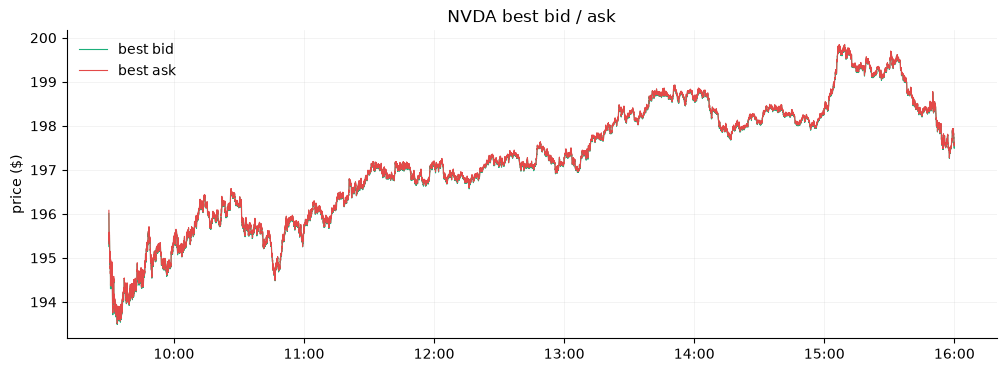

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data_second = data[["bid_px_00", "ask_px_00"]].resample("1s").last()
data_second["spread"] = data_second["ask_px_00"] - data_second["bid_px_00"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data_second.index, data_second["bid_px_00"], color="#1baf7a", lw=0.8, label="best bid")
ax.plot(data_second.index, data_second["ask_px_00"], color="#e34948", lw=0.8, label="best ask")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=data_second.index.tz))
ax.set_ylabel("price ($)")
ax.set_title("NVDA best bid / ask")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
plt.show()

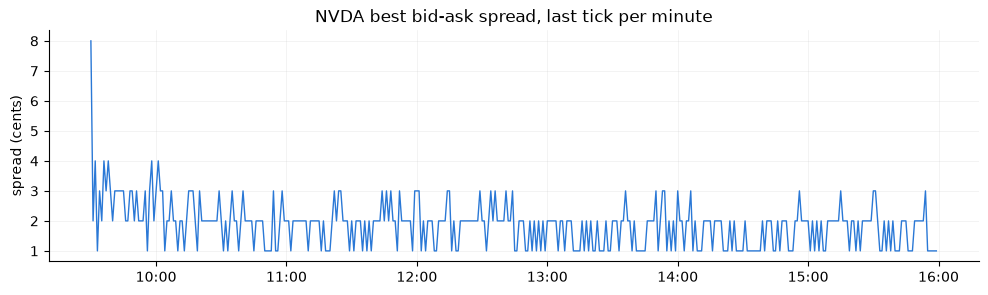

In [40]:
fig, ax = plt.subplots(figsize=(12, 3))
data_minute = data_second["spread"].resample("60s").last() * 100
ax.plot(data_minute.index, data_minute, color="#2a78d6", lw=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=data_second.index.tz))
ax.set_ylabel("spread (cents)")
ax.set_title("NVDA best bid-ask spread, last tick per minute")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
plt.show()

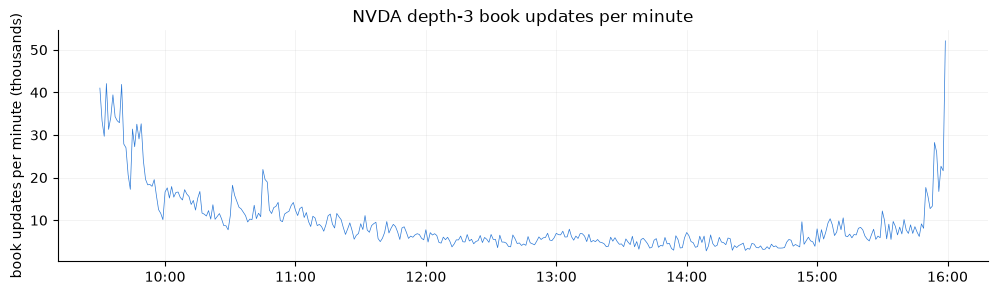

In [41]:
fig, ax = plt.subplots(figsize=(12, 3))
updates = data.resample("60s").size()/1000
ax.plot(updates.index, updates, color="#2a78d6", lw=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=updates.index.tz))
ax.set_ylabel("book updates per minute (thousands)")
ax.set_title("NVDA depth-3 book updates per minute")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
plt.show()

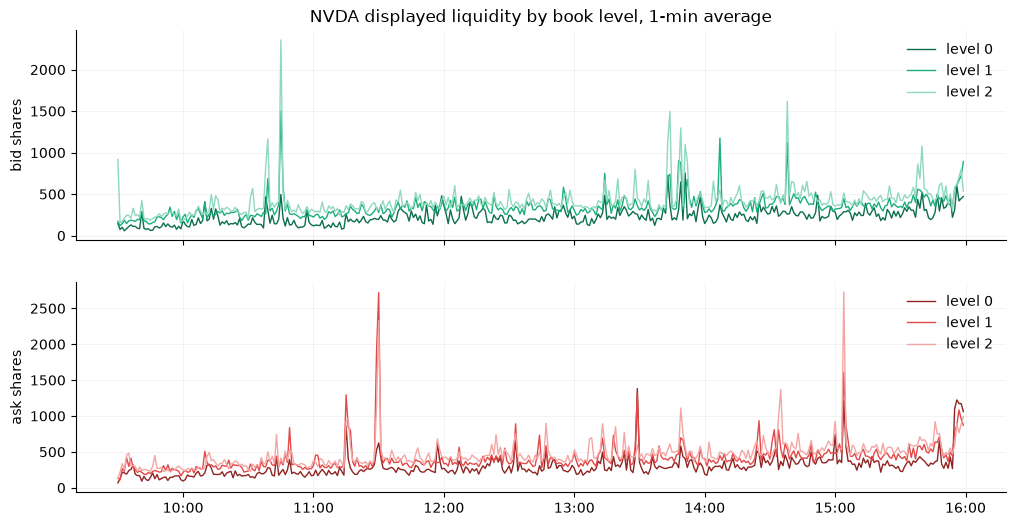

In [42]:
bid_sz_cols = [f"bid_sz_0{i}" for i in range(3)]
ask_sz_cols = [f"ask_sz_0{i}" for i in range(3)]

sz = data[bid_sz_cols + ask_sz_cols].resample("1s").last()
liq_1min = sz.resample("60s").mean()

bid_colors = ["#0b6e4c", "#1baf7a", "#8fd9bd"]  # level 0 darkest
ask_colors = ["#8f2422", "#e34948", "#f3a6a4"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in range(3):
    ax1.plot(liq_1min.index, liq_1min[f"bid_sz_0{i}"], color=bid_colors[i], lw=1, label=f"level {i}")
    ax2.plot(liq_1min.index, liq_1min[f"ask_sz_0{i}"], color=ask_colors[i], lw=1, label=f"level {i}")

ax1.set_ylabel("bid shares")
ax1.set_title("NVDA displayed liquidity by book level, 1-min average")
ax1.legend(frameon=False)

ax2.set_ylabel("ask shares")
ax2.legend(frameon=False)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=liq_1min.index.tz))

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)
plt.show()